# Combined Sherwood et al. 2020 model — Google Colab edition

Self-contained Colab notebook for the [Sherwood et al. (2020)](https://doi.org/10.1029/2019RG000678) Bayesian ECS calculation.
Runs both the UL (uniform-$\lambda$) and US (uniform-$S$) baselines and compares to Sherwood Table 10.

Unlike the local-only version (`SherwoodWebb_baselines.ipynb`), this notebook **embeds the Stan model source**
as a `%%writefile` cell rather than reading `SherwoodWebb.stan` from disk.
Runtime → Run all, and everything you need is downloaded and built in-place.

Total runtime on a free Colab CPU: ~3-4 minutes. most of it in installing ghe cmdstanpy library via PyPi and in compiling the stan binary - both one offs.`!pip install cmdstanpy`). The sampling itself should take < 1 minute.

## 1. Install libraries and Stan


In [16]:

import os
import shutil
import urllib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# Install stan

# Install pre-built CmdStan binary to avoid recompiling cmdstan via install_cmdstan in the colab VM (10 minutes +)
# Following instructions here: https://mc-stan.org/learn-stan/case-studies/jupyter_colab_notebooks_2020.html
# This can be avoided on a local machine by installing cmdstanpy via conda
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install --upgrade cmdstanpy
    # Install pre-built CmdStan binary
    # (faster than compiling from source via install_cmdstan() function)
    tgz_file = 'colab-cmdstan-2.36.0.tar.gz'
    tgz_url = 'https://github.com/stan-dev/cmdstan/releases/download/v2.36.0/colab-cmdstan-2.36.0.tgz'
    if not os.path.exists(tgz_file):
      urllib.request.urlretrieve(tgz_url, tgz_file)
      shutil.unpack_archive(tgz_file)

    # Specify CmdStan location via environment variable
    os.environ['CMDSTAN'] = './cmdstan-2.36.0'

    # Check CmdStan path
    import cmdstanpy
    cmdstanpy.cmdstan_path()


## 2. The Stan model

Write the `.stan` source to a file. `%%writefile` is a Jupyter magic that takes the rest of the cell verbatim
and writes it to the given path; the Stan code itself isn't executed by Python.

In [17]:
%%writefile /tmp/SherwoodWebb.stan
//Sherwood et al. 2020 Bayesian model.

data {
    // Prior choice: 0 = US, 1 = UL
    int<lower=0, upper=1> use_uniform_lambda_prior;

    // ---- Process likelihood (Sherwood Table 1, aggregate) ----
    // The sum of 11 individual feedback Gaussians (convolves to N(-1.30, 0.44)).
    real          mu_lambda;
    real<lower=0> sig_lambda;

    // ---- Forcing (Sherwood sec. 3.2.1) ----
    real          mu_F2xCO2;
    real<lower=0> sig_F2xCO2;

    // ---- State-dependence (Sherwood Table 7/8) ----
    real          mu_zeta;
    real<lower=0> sig_zeta;

    // ---- Historical (Sherwood Table 5, baseline row) ----
    real          mu_T_hist;
    real<lower=0> sig_T_hist;

    real          mu_N_hist;
    real<lower=0> sig_N_hist;

    real          mu_F_hist;
    real<lower=0> sig_F_hist_low;
    real<lower=0> sig_F_hist_high;

    real          mu_dlambda;
    real<lower=0> sig_dlambda;

    // ---- LGM (Sherwood Table 7) ----
    real          mu_T_LGM;
    real<lower=0> sig_T_LGM;

    real          mu_F_LGM;
    real<lower=0> sig_F_LGM;

    real          mu_alpha;
    real<lower=0> sig_alpha;

    // ---- Pliocene (Sherwood Table 8) ----
    real          mu_T_plio;
    real<lower=0> sig_T_plio;

    real          mu_CO2_plio;
    real<lower=0> sig_CO2_plio;

    real          mu_fCH4;
    real<lower=0> sig_fCH4;

    real          mu_fESS;
    real<lower=0> sig_fESS;
}
parameters {
    // The sampling space: the independent parameters that are Monte Carlo sampled
    real <lower=0.1, upper=20> S;
    real F_2xCO2;
    real zeta;

    // historical nuisance parameters
    real F_z;
    real <lower=0> N_hist;
    real dlambda;

    // LGM nuisance
    real <upper=0> T_LGM;
    real alpha;

    // Pliocene nuisance
    real <lower=0> CO2_plio;
    real fCH4;
    real fESS;
}
transformed parameters{

    // These are dependent parameters that are a function of the independent parameters
    real l;        // lambda
    real T_hist;
    real F_LGM;
    real F_plio;
    real T_plio;

    //historical forcing is independnt but needs to be reparameterized
    // so that it is smooth in sampling space ()
    real F_hist;


    // parameter formulas

    // feedback
    l       = -F_2xCO2 / S;

    // reparameterizing historical forcing
    F_hist  = F_z < 0 ? mu_F_hist + F_z * sig_F_hist_low
                      : mu_F_hist + F_z * sig_F_hist_high;

    // coupling equations
    T_hist  = -(F_hist - N_hist) / (l-dlambda);

    F_LGM   = 0.57*F_2xCO2 - T_LGM*(l/(1+zeta) + alpha/2*T_LGM);

    F_plio  = log(CO2_plio/284) / log(2) * F_2xCO2;
    T_plio  = (-F_plio*(1+fCH4)*(1+fESS)) / (l/(1+zeta));
}
model {
    // Shared
    F_2xCO2 ~ normal(mu_F2xCO2, sig_F2xCO2);
    zeta    ~ normal(mu_zeta, sig_zeta);

    // Process likelihood
    l ~ normal(mu_lambda, sig_lambda);

    // Historical
    F_z     ~ std_normal();
    N_hist  ~ normal(mu_N_hist , sig_N_hist);
    T_hist  ~ normal(mu_T_hist , sig_T_hist);
    dlambda ~ normal(mu_dlambda, sig_dlambda);

    // LGM
    T_LGM   ~ normal(mu_T_LGM, sig_T_LGM);
    alpha   ~ normal(mu_alpha, sig_alpha);
    F_LGM   ~ normal(mu_F_LGM, sig_F_LGM);

    // Pliocene
    CO2_plio ~ normal(mu_CO2_plio, sig_CO2_plio);
    fCH4     ~ normal(mu_fCH4, sig_fCH4);
    fESS     ~ normal(mu_fESS, sig_fESS);
    T_plio   ~ normal(mu_T_plio, sig_T_plio);

    // UL prior: convert from default (uniform-S) to uniform-lambda
    // by multiplying by the Jacobian (or its inverse)
    if (use_uniform_lambda_prior == 1)
        target += log(F_2xCO2) - 2 * log(S);
}

Overwriting /tmp/SherwoodWebb.stan


# 3. Sherwood baseline values

Process: aggregate of 11 Gaussian feedback components (Table 1). Historical: Table 5 BASELINE row. Paleo: Tables 7 (LGM) and 8 (mPWP).

The only difference between the UL and US data files is the integer flag `use_uniform_lambda_prior`.

In [25]:
# INPUT PARAMETER BLOCK

# -------------Posterior sample size-------------
N_CHAINS=4
N_WARMUP=5000
N_SAMPLES=50000

#Timing: ~ 1 sec / 5,000 samples with 4 chains
# e.g. 220,000 samples (N=4 chains)x(5000 warmups + 50,000 samples) takes ~1 min

#scaling between 5-95 percentiles and sigma for a gaussian:
PCT = 1.645   # 5/95 -> 1.645 sigma

#-------------Baseline values from Sherwood (pyCmndStan takes in data as a dictionary)-------------
BASE = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       4.0,  'sig_F2xCO2':      0.3,
    'mu_zeta':         0.06, 'sig_zeta':        0.20,
    # -------------Process-------------
    'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    # -------------Historical-------------
    'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    'mu_F_hist':       1.83,
    'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # -------------mid-Pliocene-------------
    'mu_T_plio':       3.0,  'sig_T_plio':      1.0,
    'mu_CO2_plio':     375.0,'sig_CO2_plio':    25.0,
    'mu_fCH4':         0.4,  'sig_fCH4':        0.1,
    'mu_fESS':         0.5,  'sig_fESS':        0.25,
}

# flag for choosing uniform lambda or uniform S
data_UL = dict(BASE, use_uniform_lambda_prior=1)
data_US = dict(BASE, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
init = dict(S=3.0, F_2xCO2=4.0, zeta=0.06,
            F_z=0.0, N_hist=0.6, dlambda=0.5,
            T_LGM=-5.0, alpha=0.1,
            CO2_plio=375.0, fCH4=0.4, fESS=0.5)

# Sherwood Table 10 reference values: (P5, P17, P50, P83, P95, mean)
SHERWOOD_UL = (2.3, 2.6, 3.1, 3.9, 4.7, 3.2)
SHERWOOD_US = (2.4, 2.8, 3.5, 4.5, 5.7, 3.7)

## 4. Compile the model

First run compiles the C++; subsequent runs reuse the cached binary (a minute or so on first run, instant after).

In [26]:
model = cmdstanpy.CmdStanModel(stan_file='/tmp/SherwoodWebb.stan')
print('binary:', model.exe_file)

binary: /tmp/SherwoodWebb


## 5. Sample both baselines

Each fit: 4 chains x (5000 warmup + 50 000 sampling), `adapt_delta=0.95`.

~30 secs per fit, ~1 min total on Colab CPU.

In [27]:
cmdstanpy.write_stan_json('/tmp/baseline_UL.json', data_UL)
cmdstanpy.write_stan_json('/tmp/baseline_US.json', data_US)

common = dict(inits=init, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=False)

fit_UL = model.sample(data='/tmp/baseline_UL.json', **common)
fit_US = model.sample(data='/tmp/baseline_US.json', **common)

S_UL = fit_UL.draws_xr(vars=['S']).S.values.ravel()
S_US = fit_US.draws_xr(vars=['S']).S.values.ravel()

18:29:58 - cmdstanpy - INFO - CmdStan start processing
18:29:58 - cmdstanpy - INFO - Chain [1] start processing
18:29:58 - cmdstanpy - INFO - Chain [2] start processing
18:30:09 - cmdstanpy - INFO - Chain [2] done processing
18:30:09 - cmdstanpy - INFO - Chain [3] start processing
18:30:21 - cmdstanpy - INFO - Chain [1] done processing
18:30:21 - cmdstanpy - INFO - Chain [4] start processing
18:30:32 - cmdstanpy - INFO - Chain [3] done processing
18:30:34 - cmdstanpy - INFO - Chain [4] done processing
18:30:34 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 57 divergent transitions (0.1%)
	Chain 4 had 3 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.
18:30:34 - cmdstanpy - INFO - CmdStan start processing
18:30:34 - cmdstanpy - INFO - Chain [1] start processing
18:30:34 - cmdstanpy - INFO - Chain [2] start processing
18:30:49 - cmdstanpy - INFO - Chain [1] done processing
18:30:49 - cmdstanpy -

## 6. Summary

In [30]:
def line(label, S, fit, sherwood):
    p5, p17, p50, p83, p95 = np.percentile(S, [5, 17, 50, 83, 95])
    div = int(np.sum(fit.method_variables()['divergent__']))
    print(f'=== {label} ===')
    print(f'  n_draws       : {len(S)}')
    print(f'  mean +/- std  : {S.mean():.2f} +/- {S.std():.2f}')
    print(f'  divergences   : {div}')
    print()
    print(f'  First row: Sherwood Table 10 reference ({label}):')
    print(f'  Second row: Stan estimate ({label}):')
    print(f'    P5  P17  P50  P83  P95   mean')
    print(f'    {sherwood[0]:.2f} {sherwood[1]:.2f}  {sherwood[2]:.2f} {sherwood[3]:.2f}  {sherwood[4]:.2f}   {sherwood[5]:.2f}')
    print(f'    {p5:.2f} {p17:.2f}  {p50:.2f} {p83:.2f}  {p95:.2f}   {S.mean():.2f}')
    print()

line('UL baseline', S_UL, fit_UL, SHERWOOD_UL)
line('US baseline', S_US, fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 200000
  mean +/- std  : 3.27 +/- 0.82
  divergences   : 60

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.22 2.55  3.13 3.95  4.78   3.27

=== US baseline ===
  n_draws       : 200000
  mean +/- std  : 3.70 +/- 1.07
  divergences   : 110

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.41 2.80  3.50 4.54  5.66   3.70



## 7. Plot

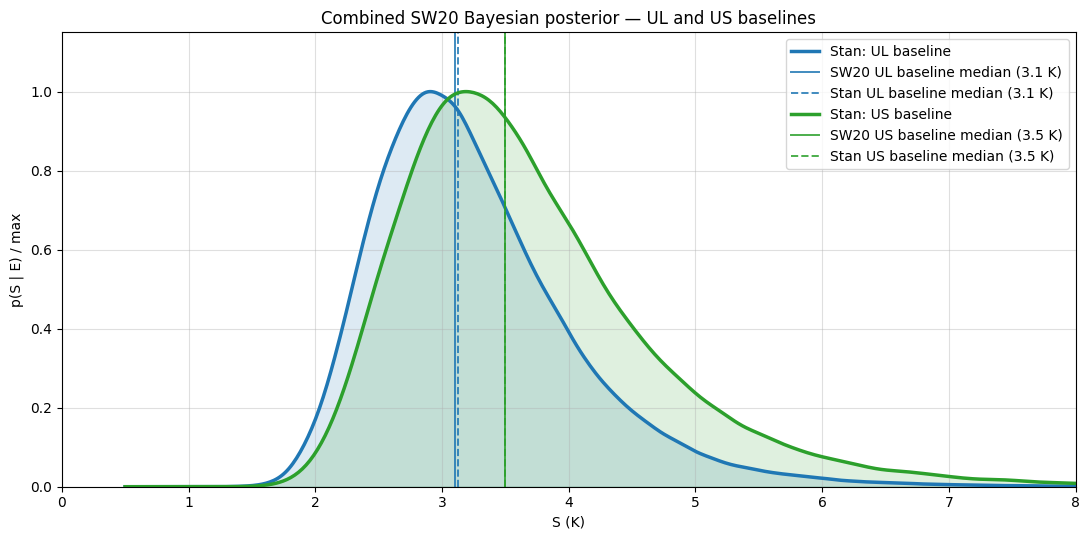

In [31]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid); pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)

    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlabel('S (K)');
ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()